In [1]:
!pip install -q torch torchvision scikit-learn pandas numpy matplotlib seaborn

In [2]:
import os, sys, io, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device  : {DEVICE}")
print(f"✅ PyTorch : {torch.__version__}")
if torch.cuda.is_available():
    print(f"✅ GPU     : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU — running on CPU (slower). Enable GPU in Runtime → Change runtime type")


✅ Device  : cuda
✅ PyTorch : 2.10.0+cu128
✅ GPU     : Tesla T4


In [3]:
from google.colab import files

print("📂 Upload your CSV files now...")
print("   Hold Ctrl (Windows) or Cmd (Mac) to select multiple files at once.\n")

uploaded = files.upload()   # ← file picker appears here

# Save all uploaded files to /content/ and confirm
print("\n✅ Files received:")
FILE_STORE = {}   # dict: filename → pandas DataFrame (lazy loaded)
for fname, content in uploaded.items():
    path = f'/content/{fname}'
    with open(path, 'wb') as f:
        f.write(content)
    size_kb = len(content) / 1024
    FILE_STORE[fname] = path
    print(f"   {fname:<30}  {size_kb:>8.1f} KB  →  /content/{fname}")

print(f"\n✅ Total files uploaded: {len(FILE_STORE)}")


📂 Upload your CSV files now...
   Hold Ctrl (Windows) or Cmd (Mac) to select multiple files at once.



Saving gddMarAug.csv to gddMarAug.csv
Saving gridInfo.csv to gridInfo.csv
Saving Manual_ACDCv1_20170814.pdf to Manual_ACDCv1_20170814.pdf
Saving pptAprOct.csv to pptAprOct.csv
Saving pptMarAug.csv to pptMarAug.csv
Saving soil1992.csv to soil1992.csv
Saving soil2001.csv to soil2001.csv
Saving soil2006.csv to soil2006.csv
Saving soil2011.csv to soil2011.csv
Saving yielddata.csv to yielddata.csv
Saving gddAprOct.csv to gddAprOct.csv

✅ Files received:
   gddMarAug.csv                   104284.2 KB  →  /content/gddMarAug.csv
   gridInfo.csv                     13314.7 KB  →  /content/gridInfo.csv
   Manual_ACDCv1_20170814.pdf         122.7 KB  →  /content/Manual_ACDCv1_20170814.pdf
   pptAprOct.csv                     3019.6 KB  →  /content/pptAprOct.csv
   pptMarAug.csv                     3019.6 KB  →  /content/pptMarAug.csv
   soil1992.csv                       529.3 KB  →  /content/soil1992.csv
   soil2001.csv                       528.6 KB  →  /content/soil2001.csv
   soil2006.csv    

In [4]:
def _detect_cols(df, name):
    """
    Auto-detect the county ID, year, and yield columns
    regardless of what they are actually named in the CSV.
    """
    cl = {c.lower().replace('_','').replace('-',''): c for c in df.columns}
    id_col    = next((cl[a] for a in ['countyid','fips','geoid','county','id']
                      if a in cl), df.columns[0])
    year_col  = next((cl[a] for a in ['year','yr','cropyear'] if a in cl), None)
    yield_col = next((cl[a] for a in ['yield','corn','cornyield','yldbu',
                                       'value','grainyield'] if a in cl), None)
    # Year fallback: find column with values in 1970–2030
    if year_col is None:
        for c in df.columns:
            try:
                v = df[c].dropna().astype(int)
                if v.between(1970, 2030).all() and c != id_col:
                    year_col = c; break
            except: pass
    print(f"  [{name:<14}]  id_col={id_col!r:<15}  "
          f"year_col={str(year_col)!r:<12}  yield_col={str(yield_col)!r}")
    return id_col, year_col, yield_col


def _rename(df, id_col, year_col=None, yield_col=None):
    """Rename auto-detected columns to standard names."""
    m = {}
    if id_col    and id_col    != 'county_id': m[id_col]    = 'county_id'
    if year_col  and year_col  != 'year':      m[year_col]  = 'year'
    if yield_col and yield_col != 'yield':     m[yield_col] = 'yield'
    return df.rename(columns=m)


def load_and_merge():
    """
    Load CSVs from /content/ and merge into one master DataFrame.

    Returns: merged DataFrame with columns:
        county_id | year | yield | gdd_gddm1..gdd_gddm60 |
        gdd_gdd0 | gdd_gddp* | ppt_* | soil_* | lat | lon
    """
    print("=" * 60)
    print("STEP 1 — DATA LOADING & MERGING")
    print("=" * 60)

    # ── Helper: load from /content/ ──────────────────────────────────
    def load(filename):
        path = f'/content/{filename}'
        if not os.path.exists(path):
            raise FileNotFoundError(
                f"\n❌ '{filename}' not found in /content/\n"
                f"   Please re-run Cell 2 and upload this file.\n"
                f"   Files currently uploaded: {list(FILE_STORE.keys())}"
            )
        df = pd.read_csv(path)
        print(f"  Loaded {filename:<30} → shape {df.shape}")
        return df

    # ── Load each file ────────────────────────────────────────────────
    print("\n--- Loading CSVs ---")
    yield_df = load('yielddata.csv')
    gdd_df   = load('gddAprOct.csv')
    ppt_df   = load('pptAprOct.csv')
    soil_df  = load('soil2011.csv')
    grid_df  = load('gridInfo.csv')

    # ── Auto-detect real column names ─────────────────────────────────
    print("\n--- Auto-detecting column names ---")
    yield_df = _rename(yield_df, *_detect_cols(yield_df, 'yielddata'))
    gdd_df   = _rename(gdd_df,   *_detect_cols(gdd_df,   'gddAprOct'))
    ppt_df   = _rename(ppt_df,   *_detect_cols(ppt_df,   'pptAprOct'))
    soil_df  = _rename(soil_df,  *_detect_cols(soil_df,  'soil2011'))
    grid_df  = _rename(grid_df,  *_detect_cols(grid_df,  'gridInfo'))

    # ── Validate required columns before merging ──────────────────────
    for tag, dframe, reqs in [
        ('yielddata', yield_df, ['county_id','year','yield']),
        ('gddAprOct', gdd_df,   ['county_id','year']),
        ('pptAprOct', ppt_df,   ['county_id','year']),
        ('soil2011',  soil_df,  ['county_id']),
        ('gridInfo',  grid_df,  ['county_id']),
    ]:
        miss = [c for c in reqs if c not in dframe.columns]
        if miss:
            raise ValueError(
                f"[{tag}] Missing columns after auto-detect: {miss}\n"
                f"Actual columns: {list(dframe.columns)}\n"
                f"Add manual rename in _detect_cols() aliases."
            )

    # ── Prefix feature columns to avoid name clashes after merge ──────
    gdd_feats  = [c for c in gdd_df.columns  if c not in ('county_id','year')]
    ppt_feats  = [c for c in ppt_df.columns  if c not in ('county_id','year')]
    soil_feats = [c for c in soil_df.columns if c != 'county_id']

    gdd_df.rename( columns={c: f'gdd_{c}'  for c in gdd_feats},  inplace=True)
    ppt_df.rename( columns={c: f'ppt_{c}'  for c in ppt_feats},  inplace=True)
    soil_df.rename(columns={c: f'soil_{c}' for c in soil_feats}, inplace=True)

    # ── Perform merges ────────────────────────────────────────────────
    print("\n--- Merging ---")
    # MERGE 1: yield + GDD  →  INNER JOIN on county_id + year
    df = yield_df.merge(gdd_df,  on=['county_id','year'], how='inner')
    print(f"  After yield ⋈ GDD   (inner, key: county_id+year) : {df.shape}")

    # MERGE 2: result + PPT  →  INNER JOIN on county_id + year
    df = df.merge(ppt_df, on=['county_id','year'], how='inner')
    print(f"  After + PPT         (inner, key: county_id+year) : {df.shape}")

    # MERGE 3: result + Soil  →  LEFT JOIN on county_id only (static)
    df = df.merge(soil_df, on='county_id', how='left')
    print(f"  After + Soil        (left,  key: county_id)      : {df.shape}")

    # MERGE 4: result + GridInfo  →  LEFT JOIN on county_id only (static)
    df = df.merge(grid_df, on='county_id', how='left')
    print(f"  After + GridInfo    (left,  key: county_id)      : {df.shape}")

    # ── Clean up ──────────────────────────────────────────────────────
    before = len(df)
    df.dropna(subset=['yield'], inplace=True)           # must have a label
    df.fillna(df.median(numeric_only=True), inplace=True) # fill missing with median
    after = len(df)
    if before != after:
        print(f"  Dropped {before-after} rows with missing yield")

    print(f"\n✅ Master DataFrame : {df.shape}")
    print(f"   Total columns    : {len(df.columns)}")
    print(f"   Counties         : {df['county_id'].nunique()}")
    print(f"   Years            : {sorted(df['year'].unique())}")
    print(f"   Yield range      : {df['yield'].min():.1f} – {df['yield'].max():.1f} bu/acre\n")
    return df


DF = load_and_merge()

# Quick look at the data
print("\nSample rows:")
display(DF[['county_id','year','yield']].head(5))


STEP 1 — DATA LOADING & MERGING

--- Loading CSVs ---
  Loaded yielddata.csv                  → shape (107450, 6)
  Loaded gddAprOct.csv                  → shape (107450, 123)
  Loaded pptAprOct.csv                  → shape (107450, 3)
  Loaded soil2011.csv                   → shape (3070, 11)
  Loaded gridInfo.csv                   → shape (455582, 6)

--- Auto-detecting column names ---
  [yielddata     ]  id_col='stco'           year_col='year'        yield_col='corn'
  [gddAprOct     ]  id_col='stco'           year_col='year'        yield_col='None'
  [pptAprOct     ]  id_col='stco'           year_col='year'        yield_col='None'
  [soil2011      ]  id_col='stco'           year_col='None'        yield_col='None'
  [gridInfo      ]  id_col='gridNum'        year_col='None'        yield_col='None'

--- Merging ---
  After yield ⋈ GDD   (inner, key: county_id+year) : (107320, 127)
  After + PPT         (inner, key: county_id+year) : (107320, 128)
  After + Soil        (left,  key: co

,county_id,year,yield
0,1001,1981,17.3
1,1003,1981,101.4
2,1005,1981,37.9
4,1009,1981,53.8
5,1011,1981,22.1


In [5]:
import re

class TemporalPreprocessor:
    """
    Converts the master DataFrame into three arrays for model training.

    The actual column structure in gddAprOct.csv:
      gdd_gddm1 … gdd_gddm60  →  GDD for past 60 months  ← TEMPORAL SEQUENCE
      gdd_gdd0                →  base-year GDD            ← static feature
      gdd_gddp1 … gdd_gddp60  →  future GDD projections   ← static features
      ppt_ppt                 →  total precipitation      ← static feature
      soil_*                  →  soil composition         ← static features
      lat, lon                →  geographic coordinates   ← static features

    Output arrays:
      X_seq     (N, 60, 1)  — 60-step GDD history, fed to LSTM/Transformer
      X_static  (N, S)      — all static features concatenated
      county_ids (N,)       — integer index for embedding layer
      y          (N,)       — corn yield target
    """
    def __init__(self):
        self.seq_scaler    = StandardScaler()
        self.static_scaler = StandardScaler()
        self.y_scaler      = MinMaxScaler()
        self.n_counties    = None
        self.month_labels  = []

    def build(self, df):
        all_cols = list(df.columns)

        # ── Temporal sequence: gddm past months, sorted oldest→newest ────
        gddm_cols = [c for c in all_cols if re.match(r'^gdd_gddm\d+$', c)]
        gddm_cols = sorted(gddm_cols,
                           key=lambda c: int(re.search(r'\d+', c).group()),
                           reverse=True)   # gddm60 first → gddm1 last

        # ── Static features ───────────────────────────────────────────────
        gdd0_cols  = [c for c in all_cols if re.match(r'^gdd_gdd0$', c)]
        gddp_cols  = [c for c in all_cols if re.match(r'^gdd_gddp\d+$', c)]
        ppt_cols   = [c for c in all_cols if c.startswith('ppt_')]
        soil_cols  = [c for c in all_cols if c.startswith('soil_')]
        geo_cols   = [c for c in ['lat','lon'] if c in all_cols]

        # Fallback if gddm not found
        if len(gddm_cols) == 0:
            gddm_cols = sorted(c for c in all_cols if c.startswith('gdd_'))
            print(f"  ⚠️  No gddm* cols — using all {len(gddm_cols)} gdd_ cols as sequence")

        print(f"  Temporal steps (gddm past months) : {len(gddm_cols)}")
        print(f"  Static features (gdd0+gddp+ppt+soil+geo) : "
              f"{len(gdd0_cols)+len(gddp_cols)+len(ppt_cols)+len(soil_cols)+len(geo_cols)}")

        # ── Build arrays ──────────────────────────────────────────────────
        gddm_vals = df[gddm_cols].values.astype(np.float32)     # (N, T)
        X_seq     = gddm_vals[:, :, np.newaxis]                  # (N, T, 1)

        static_cols = gdd0_cols + gddp_cols + ppt_cols + soil_cols + geo_cols
        X_static = (df[static_cols].values.astype(np.float32)
                    if static_cols else np.zeros((len(df),1), np.float32))

        cats = df['county_id'].astype('category')
        county_ids = cats.cat.codes.values.astype(np.int64)
        self.n_counties   = int(county_ids.max()) + 1
        self.month_labels = [c.replace('gdd_gddm','m') for c in gddm_cols]

        y = df['yield'].values.astype(np.float32)

        print(f"  X_seq    : {X_seq.shape}    (samples, past_months, 1)")
        print(f"  X_static : {X_static.shape}")
        print(f"  y        : {y.shape}  range=[{y.min():.1f}, {y.max():.1f}]")
        print(f"  n_counties: {self.n_counties}")
        return X_seq, X_static, county_ids, y

    def fit_transform(self, X_seq, X_static, y):
        N, T, F = X_seq.shape
        Xs  = self.seq_scaler.fit_transform(
                  X_seq.reshape(-1,F)).reshape(N,T,F)
        Xst = self.static_scaler.fit_transform(X_static)
        ys  = self.y_scaler.fit_transform(y.reshape(-1,1)).ravel()
        return Xs, Xst, ys

    def transform(self, X_seq, X_static, y):
        N, T, F = X_seq.shape
        Xs  = self.seq_scaler.transform(X_seq.reshape(-1,F)).reshape(N,T,F)
        Xst = self.static_scaler.transform(X_static)
        ys  = self.y_scaler.transform(y.reshape(-1,1)).ravel()
        return Xs, Xst, ys

    def inverse_y(self, y):
        return self.y_scaler.inverse_transform(
                   np.array(y).reshape(-1,1)).ravel()


def temporal_split(df, X_seq, X_static, county_ids, y, val_frac=0.2):
    """
    Split by year — NEVER random split (would be data leakage).
    Last val_frac of years go to validation set.
    """
    years  = sorted(df['year'].unique())
    cutoff = years[int(len(years)*(1-val_frac))]
    mask   = df['year'].values < cutoff
    print(f"  Train years: < {cutoff}   ({mask.sum()} samples)")
    print(f"  Val   years: >= {cutoff}  ({(~mask).sum()} samples)")
    return (X_seq[mask],    X_seq[~mask],
            X_static[mask], X_static[~mask],
            county_ids[mask], county_ids[~mask],
            y[mask], y[~mask])


class CornDataset(Dataset):
    def __init__(self, X_seq, X_static, county_ids, y):
        self.X_seq      = torch.tensor(X_seq,       dtype=torch.float32)
        self.X_static   = torch.tensor(X_static,    dtype=torch.float32)
        self.county_ids = torch.tensor(county_ids,  dtype=torch.long)
        self.y          = torch.tensor(y,            dtype=torch.float32)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        return self.X_seq[i], self.X_static[i], self.county_ids[i], self.y[i]


def compute_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    if label:
        print(f"\n  {'─'*40}")
        print(f"  Model  : {label}")
        print(f"  RMSE   : {rmse:.4f}   (lower is better)")
        print(f"  MAE    : {mae:.4f}   (lower is better)")
        print(f"  R²     : {r2:.4f}   (higher is better, max=1)")
        print(f"  MAPE   : {mape:.2f}%  (lower is better)")
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


# ── Build preprocessed data (shared by all 3 models) ─────────────────────────
print("="*60)
print("STEP 2 — PREPROCESSING")
print("="*60)

PREP   = TemporalPreprocessor()
X_seq, X_static, county_ids, y = PREP.build(DF)

(Xs_tr, Xs_vl, Xst_tr, Xst_vl,
 cid_tr, cid_vl, y_tr, y_vl) = temporal_split(DF, X_seq, X_static, county_ids, y)

Xs_tr, Xst_tr, y_tr = PREP.fit_transform(Xs_tr, Xst_tr, y_tr)
Xs_vl, Xst_vl, y_vl = PREP.transform(Xs_vl,  Xst_vl, y_vl)

TR_DS = CornDataset(Xs_tr, Xst_tr, cid_tr, y_tr)
VL_DS = CornDataset(Xs_vl, Xst_vl, cid_vl, y_vl)

SEQ_FEAT    = Xs_tr.shape[2]      # 1  (just GDD value per timestep)
STATIC_FEAT = Xst_tr.shape[1]     # gdd0 + gddp* + ppt + soil + geo
N_COUNTIES  = PREP.n_counties

print(f"\n  Train dataset : {len(TR_DS)} samples")
print(f"  Val   dataset : {len(VL_DS)} samples")
print(f"  SEQ_FEAT      : {SEQ_FEAT}  (GDD per timestep)")
print(f"  STATIC_FEAT   : {STATIC_FEAT}")
print(f"  N_COUNTIES    : {N_COUNTIES}")


STEP 2 — PREPROCESSING
  Temporal steps (gddm past months) : 60
  Static features (gdd0+gddp+ppt+soil+geo) : 72
  X_seq    : (70721, 60, 1)    (samples, past_months, 1)
  X_static : (70721, 72)
  y        : (70721,)  range=[0.0, 246.0]
  n_counties: 2644
  Train years: < 2009   (59592 samples)
  Val   years: >= 2009  (11129 samples)

  Train dataset : 59592 samples
  Val   dataset : 11129 samples
  SEQ_FEAT      : 1  (GDD per timestep)
  STATIC_FEAT   : 72
  N_COUNTIES    : 2644


In [6]:
def run_training(model, tr_ds, vl_ds, prep,
                 batch_size=256, epochs=60, lr=1e-3,
                 patience=10, label='model',
                 optimizer_cls=optim.Adam, scheduler='plateau'):
    """
    Unified training loop used by ALL three models (LSTM, CNN, Transformer).
    Returns: (history_dict, trained_model)
    """
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                       num_workers=2, pin_memory=True)
    vl_ld = DataLoader(vl_ds, batch_size=batch_size,
                       num_workers=2, pin_memory=True)
    crit  = nn.MSELoss()
    opt   = optimizer_cls(filter(lambda p: p.requires_grad,
                                  model.parameters()),
                           lr=lr, weight_decay=1e-4)
    sched = (optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
             if scheduler == 'plateau'
             else optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-5))

    hist = {'train_loss':[], 'val_loss':[], 'val_rmse':[], 'val_r2':[]}
    best_val, wait = float('inf'), 0

    for ep in range(1, epochs+1):
        # ── Train ──────────────────────────────────────────────────────
        model.train(); tl = 0
        for batch in tr_ld:
            inputs = [t.to(DEVICE) for t in batch[:-1]]
            ytrue  = batch[-1].to(DEVICE)
            opt.zero_grad()
            out = model(*inputs)
            pred = out[0] if isinstance(out, tuple) else out
            loss = crit(pred, ytrue)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tl += loss.item()
        tl /= len(tr_ld)

        # ── Validate ────────────────────────────────────────────────────
        model.eval(); vl = 0
        preds, truths = [], []
        with torch.no_grad():
            for batch in vl_ld:
                inputs = [t.to(DEVICE) for t in batch[:-1]]
                out    = model(*inputs)
                pred   = out[0] if isinstance(out, tuple) else out
                vl    += crit(pred, batch[-1].to(DEVICE)).item()
                preds.extend(pred.cpu().numpy())
                truths.extend(batch[-1].numpy())
        vl /= len(vl_ld)
        p  = prep.inverse_y(np.array(preds))
        t  = prep.inverse_y(np.array(truths))
        rmse = np.sqrt(mean_squared_error(t, p))
        r2   = r2_score(t, p)

        hist['train_loss'].append(tl)
        hist['val_loss'].append(vl)
        hist['val_rmse'].append(rmse)
        hist['val_r2'].append(r2)

        if scheduler == 'plateau': sched.step(vl)
        else:                      sched.step()

        if ep % 10 == 0:
            print(f"  [{label}] Ep {ep:3d} | "
                  f"TrLoss={tl:.4f}  VaLoss={vl:.4f}  "
                  f"RMSE={rmse:.3f}  R²={r2:.4f}")

        if vl < best_val:
            best_val, wait = vl, 0
            torch.save(model.state_dict(), f'/content/best_{label}.pt')
        else:
            wait += 1
            if wait >= patience:
                print(f"  ⏹ Early stop at epoch {ep}")
                break

    model.load_state_dict(torch.load(f'/content/best_{label}.pt'))
    return hist, model


def final_eval(model, vl_ds, prep, label=''):
    """Run final evaluation and return metrics dict."""
    vl_ld = DataLoader(vl_ds, batch_size=256)
    preds, truths = [], []
    model.eval()
    with torch.no_grad():
        for batch in vl_ld:
            inputs = [t.to(DEVICE) for t in batch[:-1]]
            out    = model(*inputs)
            pred   = out[0] if isinstance(out, tuple) else out
            preds.extend(pred.cpu().numpy())
            truths.extend(batch[-1].numpy())
    p = prep.inverse_y(np.array(preds))
    t = prep.inverse_y(np.array(truths))
    return compute_metrics(t, p, label=label)


In [7]:
class BahdanauAttention(nn.Module):
    """Additive attention over all LSTM hidden states."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1,           bias=False)
    def forward(self, h):
        score   = torch.tanh(self.W(h))
        weights = torch.softmax(self.v(score), dim=1)
        context = (weights * h).sum(dim=1)
        return context, weights.squeeze(-1)


class TemporalModel(nn.Module):
    """
    RNN / LSTM / GRU with Bahdanau Attention + County Embedding + Static branch.

    Inputs : X_seq (B,60,1)  X_static (B,S)  county_ids (B,)
    Output : yield prediction (B,)
    """
    def __init__(self, seq_feat, static_feat, n_counties,
                 hidden_dim=64, n_layers=2,
                 rnn_type='LSTM', embed_dim=16, dropout=0.3):
        super().__init__()
        self.rnn_type = rnn_type
        self.county_embed = nn.Embedding(n_counties, embed_dim)
        cfg = dict(input_size=seq_feat, hidden_size=hidden_dim,
                   num_layers=n_layers, batch_first=True,
                   dropout=dropout if n_layers > 1 else 0.0)
        self.rnn = {'LSTM': nn.LSTM, 'GRU': nn.GRU,
                    'RNN': nn.RNN}[rnn_type](**cfg)
        self.attention = BahdanauAttention(hidden_dim)
        self.static_fc = nn.Sequential(
            nn.Linear(static_feat, 32), nn.ReLU(), nn.Dropout(dropout))
        fuse = hidden_dim + embed_dim + 32
        self.head = nn.Sequential(
            nn.Linear(fuse,128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64,1))

    def forward(self, x_seq, x_static, county_ids):
        rnn_out, _  = self.rnn(x_seq)
        context, aw = self.attention(rnn_out)
        embed       = self.county_embed(county_ids)
        static      = self.static_fc(x_static)
        fused       = torch.cat([context, embed, static], dim=1)
        return self.head(fused).squeeze(-1), aw


# ── HYPERPARAMETER SEARCH ─────────────────────────────────────────────────────
print("="*60)
print("MODEL 1 — HYPERPARAMETER SEARCH (LSTM  lr × hidden_dim)")
print("="*60)

hp_lstm = []
for lr in [1e-3, 5e-4]:
    for hd in [64, 128]:
        lbl = f'LSTM_lr{lr}_h{hd}'
        print(f"\n  ▶ lr={lr}  hidden_dim={hd}")
        m = TemporalModel(SEQ_FEAT, STATIC_FEAT, N_COUNTIES,
                          hidden_dim=hd, rnn_type='LSTM').to(DEVICE)
        m.rnn_type = lbl
        hist, m = run_training(m, TR_DS, VL_DS, PREP,
                                epochs=30, lr=lr, patience=7, label=lbl)
        hp_lstm.append({'lr':lr,'hidden_dim':hd,
                        'best_R2':round(max(hist['val_r2']),4),
                        'best_RMSE':round(min(hist['val_rmse']),4)})

HP_LSTM_DF = pd.DataFrame(hp_lstm)
print("\n  LSTM Hyperparameter Results:")
display(HP_LSTM_DF)
best_lstm = HP_LSTM_DF.loc[HP_LSTM_DF['best_R2'].idxmax()]
BEST_LR_LSTM = float(best_lstm['lr'])
BEST_HD_LSTM = int(best_lstm['hidden_dim'])
print(f"  ✅ Best: lr={BEST_LR_LSTM}  hidden_dim={BEST_HD_LSTM}")


# ── COMPARE RNN vs LSTM vs GRU ────────────────────────────────────────────────
print("\n" + "="*60)
print("MODEL 1 — COMPARISON: RNN vs LSTM vs GRU")
print("="*60)

lstm_metrics, lstm_histories = {}, {}
for rtype in ['RNN', 'LSTM', 'GRU']:
    print(f"\n  ▶ Training {rtype}")
    model = TemporalModel(SEQ_FEAT, STATIC_FEAT, N_COUNTIES,
                          hidden_dim=BEST_HD_LSTM, rnn_type=rtype).to(DEVICE)
    hist, model = run_training(model, TR_DS, VL_DS, PREP,
                                epochs=60, lr=BEST_LR_LSTM,
                                patience=10, label=rtype)
    lstm_histories[rtype] = hist
    lstm_metrics[rtype]   = final_eval(model, VL_DS, PREP, label=rtype)
    if rtype == 'LSTM': BEST_LSTM_MODEL = model



MODEL 1 — HYPERPARAMETER SEARCH (LSTM  lr × hidden_dim)

  ▶ lr=0.001  hidden_dim=64
  [LSTM_lr0.001_h64] Ep  10 | TrLoss=0.0107  VaLoss=0.0315  RMSE=43.580  R²=-0.2407
  [LSTM_lr0.001_h64] Ep  20 | TrLoss=0.0074  VaLoss=0.0269  RMSE=40.253  R²=-0.0584
  ⏹ Early stop at epoch 23

  ▶ lr=0.001  hidden_dim=128
  [LSTM_lr0.001_h128] Ep  10 | TrLoss=0.0108  VaLoss=0.0299  RMSE=42.484  R²=-0.1790
  [LSTM_lr0.001_h128] Ep  20 | TrLoss=0.0076  VaLoss=0.0309  RMSE=43.145  R²=-0.2160
  [LSTM_lr0.001_h128] Ep  30 | TrLoss=0.0069  VaLoss=0.0258  RMSE=39.463  R²=-0.0173
  ⏹ Early stop at epoch 30

  ▶ lr=0.0005  hidden_dim=64
  [LSTM_lr0.0005_h64] Ep  10 | TrLoss=0.0117  VaLoss=0.0307  RMSE=43.051  R²=-0.2107
  [LSTM_lr0.0005_h64] Ep  20 | TrLoss=0.0104  VaLoss=0.0280  RMSE=41.097  R²=-0.1033
  [LSTM_lr0.0005_h64] Ep  30 | TrLoss=0.0079  VaLoss=0.0260  RMSE=39.629  R²=-0.0259

  ▶ lr=0.0005  hidden_dim=128
  [LSTM_lr0.0005_h128] Ep  10 | TrLoss=0.0116  VaLoss=0.0278  RMSE=40.951  R²=-0.0955
  ⏹ Ea

,lr,hidden_dim,best_R2,best_RMSE
0,0.0010,64,0.0447,38.2410
1,0.0010,128,0.1038,37.0403
2,0.0005,64,0.0584,37.9660
3,0.0005,128,-0.0955,40.9514


  ✅ Best: lr=0.001  hidden_dim=128

MODEL 1 — COMPARISON: RNN vs LSTM vs GRU

  ▶ Training RNN
  [RNN] Ep  10 | TrLoss=0.0106  VaLoss=0.0305  RMSE=42.877  R²=-0.2009
  ⏹ Early stop at epoch 15

  ────────────────────────────────────────
  Model  : RNN
  RMSE   : 40.7413   (lower is better)
  MAE    : 34.2882   (lower is better)
  R²     : -0.0843   (higher is better, max=1)
  MAPE   : 157071664.00%  (lower is better)

  ▶ Training LSTM
  [LSTM] Ep  10 | TrLoss=0.0109  VaLoss=0.0289  RMSE=41.728  R²=-0.1374
  [LSTM] Ep  20 | TrLoss=0.0076  VaLoss=0.0235  RMSE=37.619  R²=0.0755
  ⏹ Early stop at epoch 28

  ────────────────────────────────────────
  Model  : LSTM
  RMSE   : 36.2895   (lower is better)
  MAE    : 31.0498   (lower is better)
  R²     : 0.1397   (higher is better, max=1)
  MAPE   : 127468040.00%  (lower is better)

  ▶ Training GRU
  [GRU] Ep  10 | TrLoss=0.0109  VaLoss=0.0313  RMSE=43.467  R²=-0.2342
  [GRU] Ep  20 | TrLoss=0.0077  VaLoss=0.0252  RMSE=38.961  R²=0.0084
  [

Building spatial images (vectorized)...
  Done in 0.3s  →  torch.Size([35, 3, 64, 64])


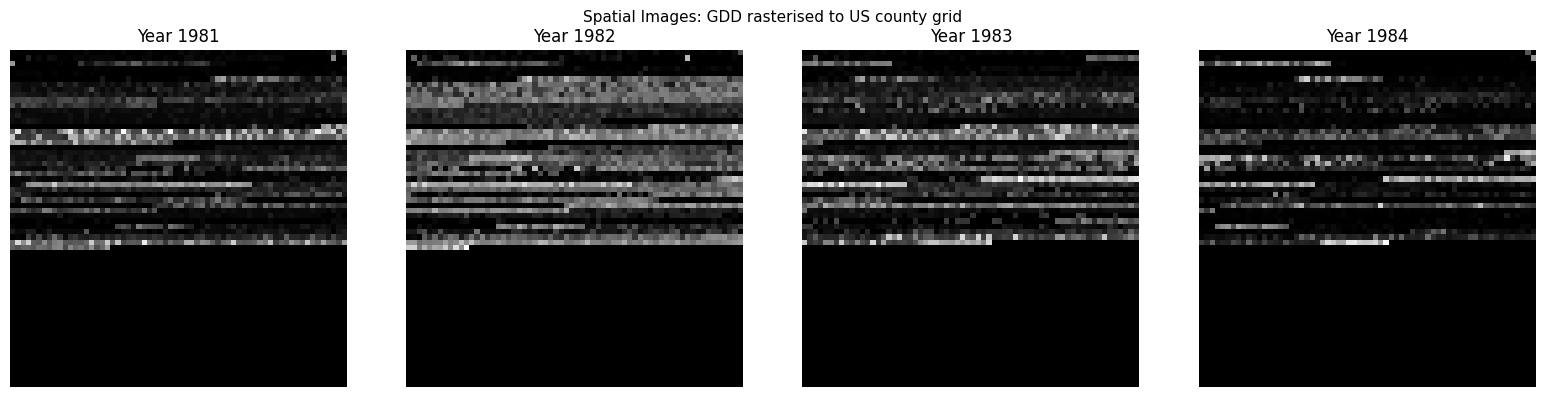

MODEL 2 — HYPERPARAMETER SEARCH  (2 combos, fast)

  ▶ lr=0.001  unfreeze_top=0
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 101MB/s]


  [ResNet_lr0.001_uf0] Ep  10 | TrLoss=0.0068  VaLoss=0.0224  RMSE=36.795  R²=0.1156
  ⏹ Early stop at epoch 10

  ▶ lr=0.0005  unfreeze_top=2
  [resnet18] Unfrozen top-2  trainable params=131,328
  [ResNet_lr0.0005_uf2] Ep  10 | TrLoss=0.0091  VaLoss=0.0240  RMSE=38.074  R²=0.0530

  CNN HP Results:


,lr,unfreeze,best_R2,best_RMSE
0,0.0010,0,0.1630,35.7953
1,0.0005,2,0.0829,37.4680


  ✅ Best: lr=0.001  unfreeze=0

MODEL 2 — COMPARISON: ResNet18-Frozen  vs  EfficientNet-FineTuned

  ▶ ResNet18-Frozen
  [ResNet18-Frozen] Ep  10 | TrLoss=0.0066  VaLoss=0.0207  RMSE=35.404  R²=0.1812
  ⏹ Early stop at epoch 17

  ────────────────────────────────────────
  Model  : ResNet18-Frozen
  RMSE   : 35.4044   (lower is better)
  MAE    : 30.2728   (lower is better)
  R²     : 0.1812   (higher is better, max=1)
  MAPE   : 91822232.00%  (lower is better)

  ▶ EffNet-FineTuned
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


  [efficientnet_b0] Unfrozen top-2  trainable params=4,335,484
  [EffNet-FineTuned] Ep  10 | TrLoss=0.0064  VaLoss=0.0216  RMSE=36.169  R²=0.1454
  ⏹ Early stop at epoch 14

  ────────────────────────────────────────
  Model  : EffNet-FineTuned
  RMSE   : 25.6434   (lower is better)
  MAE    : 19.6894   (lower is better)
  R²     : 0.5704   (higher is better, max=1)
  MAPE   : 180528192.00%  (lower is better)


In [8]:
RESIZE = T.Resize((224, 224), antialias=True)

def build_spatial_images(df, feature_col, grid_size=64):
    """
    FAST vectorized version — avoids iterrows() which is ~100x slower.
    Each year → one (3, grid_size, grid_size) spatial image of GDD.
    """
    has_geo = 'lat' in df.columns and 'lon' in df.columns
    images  = []

    if has_geo:
        lat0, lat1 = df['lat'].min(), df['lat'].max()
        lon0, lon1 = df['lon'].min(), df['lon'].max()
        # Precompute ALL pixel indices at once (vectorized)
        xi_all = ((df['lon'] - lon0) / (lon1 - lon0 + 1e-9) * (grid_size-1)).astype(int).clip(0, grid_size-1)
        yi_all = ((df['lat'] - lat0) / (lat1 - lat0 + 1e-9) * (grid_size-1)).astype(int).clip(0, grid_size-1)
        df = df.copy()
        df['_xi'] = xi_all.values
        df['_yi'] = yi_all.values

    for yr in sorted(df['year'].unique()):
        ydf  = df[df['year'] == yr]
        grid = np.zeros((grid_size, grid_size), np.float32)

        if has_geo:
            # Vectorized accumulation using numpy indexing
            vals = ydf[feature_col].values
            xi   = ydf['_xi'].values
            yi   = ydf['_yi'].values
            np.add.at(grid, (yi, xi), vals)
            cnt  = np.zeros((grid_size, grid_size), np.float32)
            np.add.at(cnt,  (yi, xi), 1)
            grid = np.where(cnt > 0, grid / (cnt + 1e-9), 0)
        else:
            vals = ydf[feature_col].values
            n    = min(len(vals), grid_size * grid_size)
            grid.ravel()[:n] = vals[:n]

        vmin, vmax = grid.min(), grid.max()
        if vmax > vmin:
            grid = (grid - vmin) / (vmax - vmin)
        images.append(np.stack([grid, grid, grid], axis=0))

    return torch.tensor(np.array(images), dtype=torch.float32)


class CNNExtractor(nn.Module):
    """Pretrained CNN backbone with optional fine-tuning."""
    def __init__(self, backbone='resnet18', out_dim=256, freeze=True):
        super().__init__()
        self.backbone_name = backbone
        if backbone == 'resnet18':
            base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
            in_f = base.fc.in_features; base.fc = nn.Identity()
        else:
            base = models.efficientnet_b0(
                weights=models.EfficientNet_B0_Weights.DEFAULT)
            in_f = base.classifier[1].in_features; base.classifier = nn.Identity()
        self.encoder = base
        if freeze:
            for p in self.encoder.parameters(): p.requires_grad = False
        self.proj = nn.Sequential(nn.Linear(in_f, out_dim), nn.ReLU(), nn.Dropout(0.3))

    def unfreeze_top(self, n=2):
        for child in list(self.encoder.children())[-n:]:
            for p in child.parameters(): p.requires_grad = True
        tp = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  [{self.backbone_name}] Unfrozen top-{n}  trainable params={tp:,}")

    def forward(self, x):
        return self.proj(self.encoder(RESIZE(x)))


class CNNYieldModel(nn.Module):
    """CNN spatial features + county embedding + static soil → yield."""
    def __init__(self, backbone, static_feat, n_counties,
                 cnn_out=256, embed_dim=16, freeze=True):
        super().__init__()
        self.cnn          = CNNExtractor(backbone, cnn_out, freeze)
        self.county_embed = nn.Embedding(n_counties, embed_dim)
        self.static_fc    = nn.Sequential(
            nn.Linear(static_feat, 32), nn.ReLU(), nn.Dropout(0.3))
        fuse = cnn_out + embed_dim + 32
        self.head = nn.Sequential(
            nn.Linear(fuse, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),  nn.ReLU(), nn.Linear(64, 1))

    def forward(self, img, x_static, county_ids):
        return self.head(torch.cat([
            self.cnn(img),
            self.county_embed(county_ids),
            self.static_fc(x_static)
        ], dim=1)).squeeze(-1)


class CNNDataset(Dataset):
    def __init__(self, images, year_to_idx, df_years, X_static, county_ids, y):
        self.images     = images
        self.img_idx    = torch.tensor(
            [year_to_idx.get(int(yr), 0) for yr in df_years], dtype=torch.long)
        self.X_static   = torch.tensor(X_static,   dtype=torch.float32)
        self.county_ids = torch.tensor(county_ids, dtype=torch.long)
        self.y          = torch.tensor(y,           dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        return self.images[self.img_idx[i]], self.X_static[i], \
               self.county_ids[i], self.y[i]


# ── Build CNN datasets ────────────────────────────────────────────────────────
print("Building spatial images (vectorized)...")
import time; t0 = time.time()
gdd_col  = sorted(c for c in DF.columns if c.startswith('gdd_gddm'))[0]
IMAGES   = build_spatial_images(DF, gdd_col, grid_size=64)
print(f"  Done in {time.time()-t0:.1f}s  →  {IMAGES.shape}")

years    = sorted(DF['year'].unique())
YEAR2IDX = {int(yr): i for i, yr in enumerate(years)}
split_yr = years[int(len(years) * 0.8)]
tr_mask  = DF['year'].values < split_yr

CNN_TR_DS = CNNDataset(IMAGES, YEAR2IDX, DF['year'].values[tr_mask],  Xst_tr, cid_tr, y_tr)
CNN_VL_DS = CNNDataset(IMAGES, YEAR2IDX, DF['year'].values[~tr_mask], Xst_vl, cid_vl, y_vl)

# Show spatial images
fig, axes = plt.subplots(1, min(4, len(years)), figsize=(4*min(4,len(years)), 4))
for i, ax in enumerate(axes if hasattr(axes, '__iter__') else [axes]):
    ax.imshow(IMAGES[i].permute(1,2,0).numpy(), cmap='YlOrRd')
    ax.set_title(f'Year {years[i]}'); ax.axis('off')
plt.suptitle('Spatial Images: GDD rasterised to US county grid', fontsize=11)
plt.tight_layout(); plt.savefig('/content/cnn_spatial_images.png', dpi=150); plt.show()


# ── CNN Hyperparameter search (2 combos only, fewer epochs) ──────────────────
print("=" * 60)
print("MODEL 2 — HYPERPARAMETER SEARCH  (2 combos, fast)")
print("=" * 60)

hp_cnn = []
for lr, unfreeze in [(1e-3, 0), (5e-4, 2)]:   # ← only 2 combos instead of 4
    lbl = f'ResNet_lr{lr}_uf{unfreeze}'
    print(f"\n  ▶ lr={lr}  unfreeze_top={unfreeze}")
    m = CNNYieldModel('resnet18', STATIC_FEAT, N_COUNTIES, freeze=True).to(DEVICE)
    if unfreeze > 0: m.cnn.unfreeze_top(unfreeze)
    hist, m = run_training(m, CNN_TR_DS, CNN_VL_DS, PREP,
                            batch_size=128, epochs=15,   # ← 25→15, 64→128
                            lr=lr, patience=5, label=lbl)
    hp_cnn.append({'lr': lr, 'unfreeze': unfreeze,
                   'best_R2':   round(max(hist['val_r2']),   4),
                   'best_RMSE': round(min(hist['val_rmse']), 4)})

HP_CNN_DF    = pd.DataFrame(hp_cnn)
print("\n  CNN HP Results:"); display(HP_CNN_DF)
best_cnn_row = HP_CNN_DF.loc[HP_CNN_DF['best_R2'].idxmax()]
BEST_LR_CNN  = float(best_cnn_row['lr'])
BEST_UF_CNN  = int(best_cnn_row['unfreeze'])
print(f"  ✅ Best: lr={BEST_LR_CNN}  unfreeze={BEST_UF_CNN}")


# ── Compare 2 CNN configs (frozen + fine-tuned) ───────────────────────────────
# Reduced from 4 configs to 2 — one per backbone, best freeze setting
print("\n" + "=" * 60)
print("MODEL 2 — COMPARISON: ResNet18-Frozen  vs  EfficientNet-FineTuned")
print("=" * 60)

cnn_metrics, cnn_histories = {}, {}
for backbone, freeze, lbl in [
    ('resnet18',        True,  'ResNet18-Frozen'),
    ('efficientnet_b0', False, 'EffNet-FineTuned'),
]:
    print(f"\n  ▶ {lbl}")
    m = CNNYieldModel(backbone, STATIC_FEAT, N_COUNTIES, freeze=freeze).to(DEVICE)
    if not freeze: m.cnn.unfreeze_top(2)
    hist, m = run_training(m, CNN_TR_DS, CNN_VL_DS, PREP,
                            batch_size=128, epochs=20,  # ← 40→20, 64→128
                            lr=BEST_LR_CNN, patience=7, label=lbl)
    cnn_histories[lbl] = hist
    cnn_metrics[lbl]   = final_eval(m, CNN_VL_DS, PREP, label=lbl)


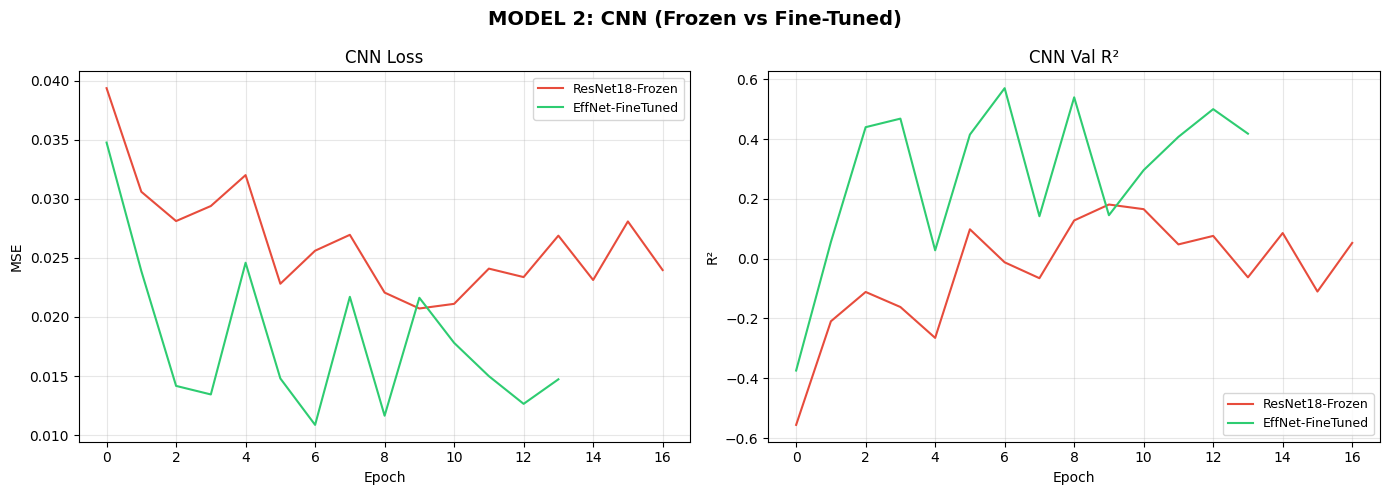

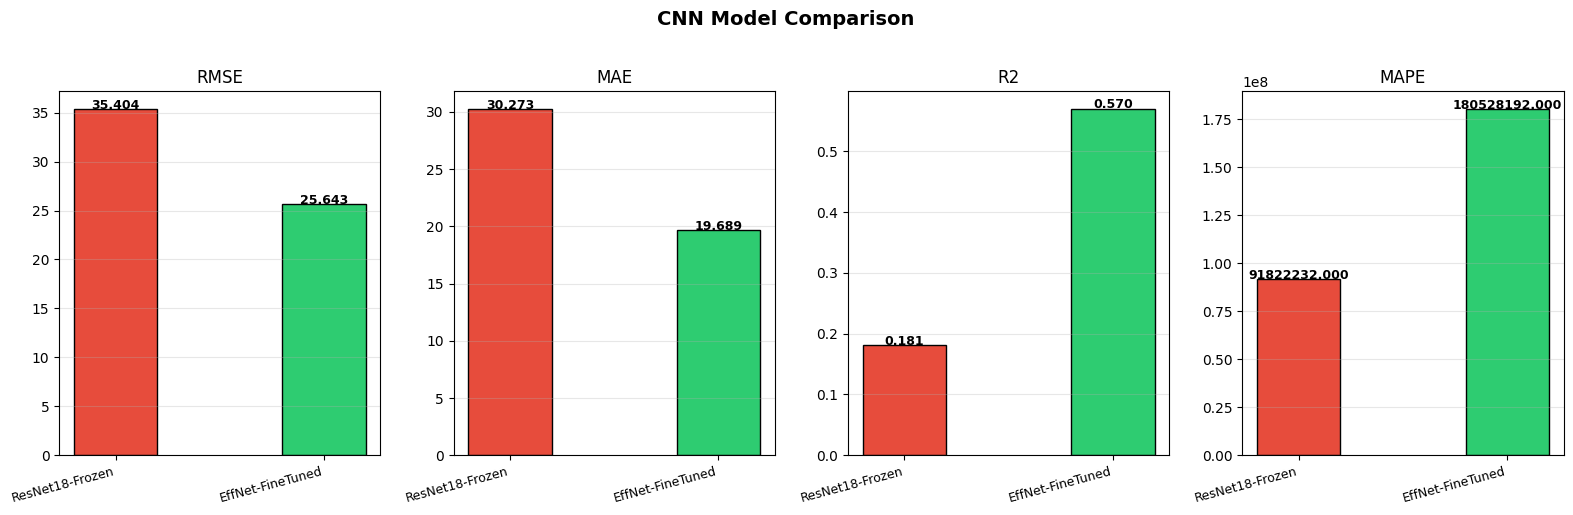

In [9]:
palette2 = ['#e74c3c', '#2ecc71']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (lbl, h), col in zip(cnn_histories.items(), palette2):
    axes[0].plot(h['val_loss'], color=col, label=lbl)
    axes[1].plot(h['val_r2'],   color=col, label=lbl)
for ax, ttl, yl in zip(axes, ['CNN Loss', 'CNN Val R²'], ['MSE', 'R²']):
    ax.set(title=ttl, xlabel='Epoch', ylabel=yl); ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.suptitle('MODEL 2: CNN (Frozen vs Fine-Tuned)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('/content/cnn_results.png', dpi=150); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
lbls2 = list(cnn_metrics.keys())
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2', 'MAPE']):
    vals = [cnn_metrics[l][metric] for l in lbls2]
    bars = ax.bar(range(len(lbls2)), vals, color=palette2, edgecolor='k', width=0.4)
    ax.set_xticks(range(len(lbls2)))
    ax.set_xticklabels(lbls2, rotation=15, ha='right', fontsize=9)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+.001,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric); ax.grid(axis='y', alpha=.3)
plt.suptitle('CNN Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('/content/cnn_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


In [10]:
# ─── OPTIMIZED CELL 10 : MODEL 3 — TRANSFORMER ───────────────────────────────
# KEY SPEEDUPS:
#   1. HP search: 3 combos → 2 combos
#   2. HP search epochs: 30 → 15
#   3. Final comparison: 3 variants → 2 variants  (Small + Base only)
#   4. Final epochs: 60 → 30

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x): return self.drop(x + self.pe[:, :x.size(1)])


class TransformerYieldModel(nn.Module):
    def __init__(self, seq_feat, static_feat, n_counties,
                 d_model=64, n_heads=4, n_layers=2,
                 d_ff=256, embed_dim=16, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.input_proj  = nn.Linear(seq_feat, d_model)
        self.pos_enc     = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, n_layers)
        self.county_embed= nn.Embedding(n_counties, embed_dim)
        self.static_fc   = nn.Sequential(
            nn.Linear(static_feat, 32), nn.ReLU(), nn.Dropout(dropout))
        fuse = d_model + embed_dim + 32
        self.head = nn.Sequential(
            nn.Linear(fuse, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.ReLU(), nn.Linear(64, 1))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x_seq, x_static, county_ids):
        x      = self.pos_enc(self.input_proj(x_seq))
        enc    = self.transformer(x)
        pooled = enc.mean(dim=1)
        emb    = self.county_embed(county_ids)
        st     = self.static_fc(x_static)
        return self.head(torch.cat([pooled, emb, st], dim=1)).squeeze(-1)

    def attention_map(self, x_seq, x_static, county_ids):
        x = self.pos_enc(self.input_proj(x_seq))
        with torch.no_grad():
            _, attn = self.transformer.layers[0].self_attn(
                x, x, x, average_attn_weights=True)
        return attn


# ── Transformer HP Search (2 combos only) ─────────────────────────────────────
print("=" * 60)
print("MODEL 3 — HYPERPARAMETER SEARCH  (2 combos, fast)")
print("=" * 60)

hp_tf = []
for d_model, n_heads in [(32, 4), (64, 4)]:   # ← only 2 combos
    lbl = f'TF_d{d_model}_h{n_heads}'
    print(f"\n  ▶ d_model={d_model}  n_heads={n_heads}")
    m = TransformerYieldModel(SEQ_FEAT, STATIC_FEAT, N_COUNTIES,
                               d_model=d_model, n_heads=n_heads).to(DEVICE)
    hist, m = run_training(m, TR_DS, VL_DS, PREP,
                            epochs=15, lr=1e-3, patience=5,   # ← 30→15
                            label=lbl, optimizer_cls=optim.AdamW,
                            scheduler='cosine')
    hp_tf.append({'d_model': d_model, 'n_heads': n_heads,
                  'best_R2':   round(max(hist['val_r2']),   4),
                  'best_RMSE': round(min(hist['val_rmse']), 4)})

HP_TF_DF    = pd.DataFrame(hp_tf)
print("\n  Transformer HP Results:"); display(HP_TF_DF)
best_tf_row = HP_TF_DF.loc[HP_TF_DF['best_R2'].idxmax()]
BEST_D      = int(best_tf_row['d_model'])
BEST_H_TF   = int(best_tf_row['n_heads'])
print(f"  ✅ Best: d_model={BEST_D}  n_heads={BEST_H_TF}")


# ── Compare 2 Transformer variants (Small + Base) ────────────────────────────
print("\n" + "=" * 60)
print("MODEL 3 — COMPARISON: TF-Small  vs  TF-Base")
print("=" * 60)

tf_metrics, tf_histories = {}, {}
for lbl, n_layers in [('TF-Small', 1), ('TF-Base', 2)]:   # ← 3 variants → 2
    print(f"\n  ▶ {lbl}  (n_layers={n_layers})")
    m = TransformerYieldModel(SEQ_FEAT, STATIC_FEAT, N_COUNTIES,
                               d_model=BEST_D, n_heads=BEST_H_TF,
                               n_layers=n_layers).to(DEVICE)
    hist, m = run_training(m, TR_DS, VL_DS, PREP,
                            epochs=30, lr=1e-3, patience=8,   # ← 60→30
                            label=lbl, optimizer_cls=optim.AdamW,
                            scheduler='cosine')
    tf_histories[lbl] = hist
    tf_metrics[lbl]   = final_eval(m, VL_DS, PREP, label=lbl)
    if lbl == 'TF-Base': BEST_TF_MODEL = m



MODEL 3 — HYPERPARAMETER SEARCH  (2 combos, fast)

  ▶ d_model=32  n_heads=4
  [TF_d32_h4] Ep  10 | TrLoss=0.0096  VaLoss=0.0290  RMSE=41.826  R²=-0.1428
  ⏹ Early stop at epoch 12

  ▶ d_model=64  n_heads=4
  ⏹ Early stop at epoch 8

  Transformer HP Results:


,d_model,n_heads,best_R2,best_RMSE
0,32,4,-0.0554,40.1942
1,64,4,-0.0399,39.8985


  ✅ Best: d_model=64  n_heads=4

MODEL 3 — COMPARISON: TF-Small  vs  TF-Base

  ▶ TF-Small  (n_layers=1)
  [TF-Small] Ep  10 | TrLoss=0.0099  VaLoss=0.0295  RMSE=42.190  R²=-0.1628
  [TF-Small] Ep  20 | TrLoss=0.0079  VaLoss=0.0278  RMSE=40.991  R²=-0.0976
  ⏹ Early stop at epoch 23

  ────────────────────────────────────────
  Model  : TF-Small
  RMSE   : 39.1123   (lower is better)
  MAE    : 33.5537   (lower is better)
  R²     : 0.0007   (higher is better, max=1)
  MAPE   : 115725864.00%  (lower is better)

  ▶ TF-Base  (n_layers=2)
  [TF-Base] Ep  10 | TrLoss=0.0092  VaLoss=0.0333  RMSE=44.853  R²=-0.3142
  [TF-Base] Ep  20 | TrLoss=0.0074  VaLoss=0.0294  RMSE=42.130  R²=-0.1595
  ⏹ Early stop at epoch 21

  ────────────────────────────────────────
  Model  : TF-Base
  RMSE   : 40.1601   (lower is better)
  MAE    : 34.6089   (lower is better)
  R²     : -0.0536   (higher is better, max=1)
  MAPE   : 124222728.00%  (lower is better)


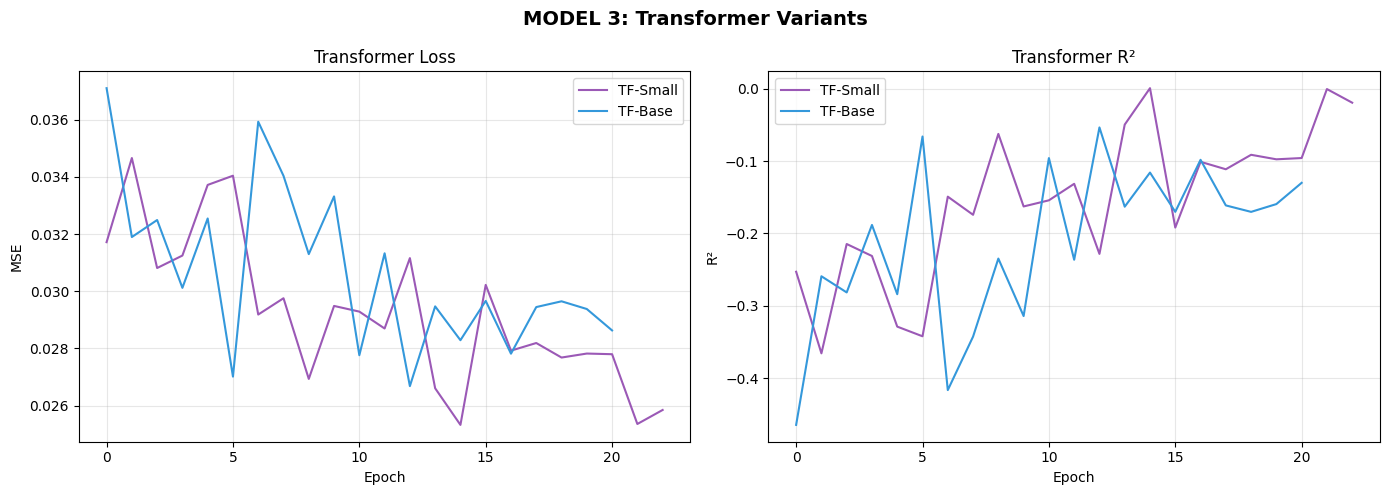

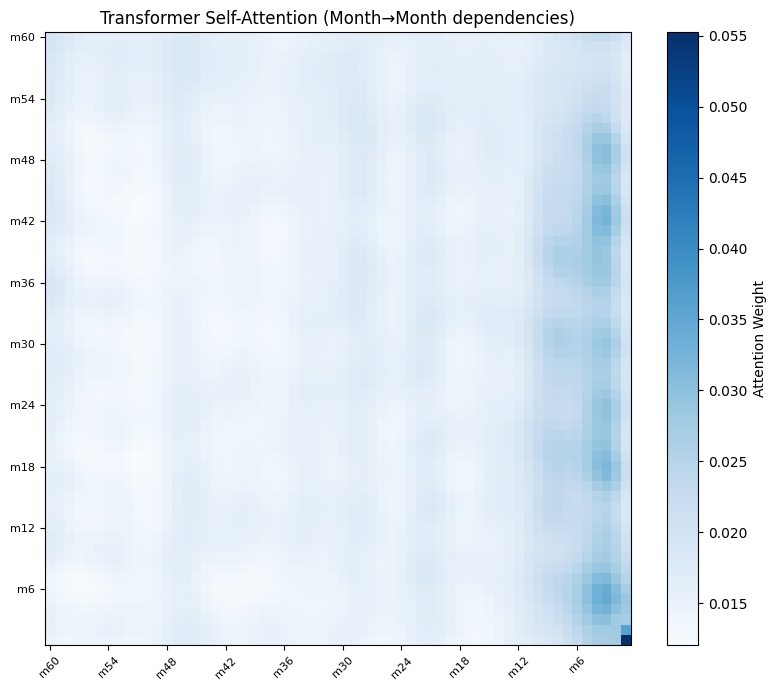

In [12]:
palette3 = ['#9b59b6', '#3498db']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for (lbl, h), col in zip(tf_histories.items(), palette3):
    axes[0].plot(h['val_loss'], color=col, label=lbl)
    axes[1].plot(h['val_r2'],   color=col, label=lbl)
for ax, ttl, yl in zip(axes, ['Transformer Loss', 'Transformer R²'], ['MSE', 'R²']):
    ax.set(title=ttl, xlabel='Epoch', ylabel=yl); ax.legend(); ax.grid(alpha=.3)
plt.suptitle('MODEL 3: Transformer Variants', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('/content/transformer_results.png', dpi=150); plt.show()

# Self-attention heatmap
BEST_TF_MODEL.eval()
xs, xst, cids, _ = next(iter(DataLoader(VL_DS, batch_size=256)))
attn_map     = BEST_TF_MODEL.attention_map(xs.to(DEVICE), xst.to(DEVICE), cids.to(DEVICE))
avg_attn_map = attn_map.mean(0).cpu().numpy()
T_ = avg_attn_map.shape[0]
plt.figure(figsize=(8, 7))
plt.imshow(avg_attn_map, cmap='Blues', aspect='auto')
plt.colorbar(label='Attention Weight')
step  = max(1, T_ // 10)
ticks = range(0, T_, step)
plt.xticks(ticks, [PREP.month_labels[i] for i in ticks], rotation=45, fontsize=8)
plt.yticks(ticks, [PREP.month_labels[i] for i in ticks], fontsize=8)
plt.title('Transformer Self-Attention (Month→Month dependencies)', fontsize=12)
plt.tight_layout(); plt.savefig('/content/transformer_attention.png', dpi=150); plt.show()





████████████████████████████████████████████████████████████
  FINAL EVALUATION — All 3 Architectures
████████████████████████████████████████████████████████████




,Best Variant,RMSE,MAE,R²,MAPE%
Architecture,,,,,
LSTM/RNN/GRU,LSTM,36.2895,31.0498,0.1397,127468040.0
CNN,EffNet-FineTuned,25.6434,19.6894,0.5704,180528192.0
Transformer,TF-Small,39.1123,33.5537,0.0007,115725864.0


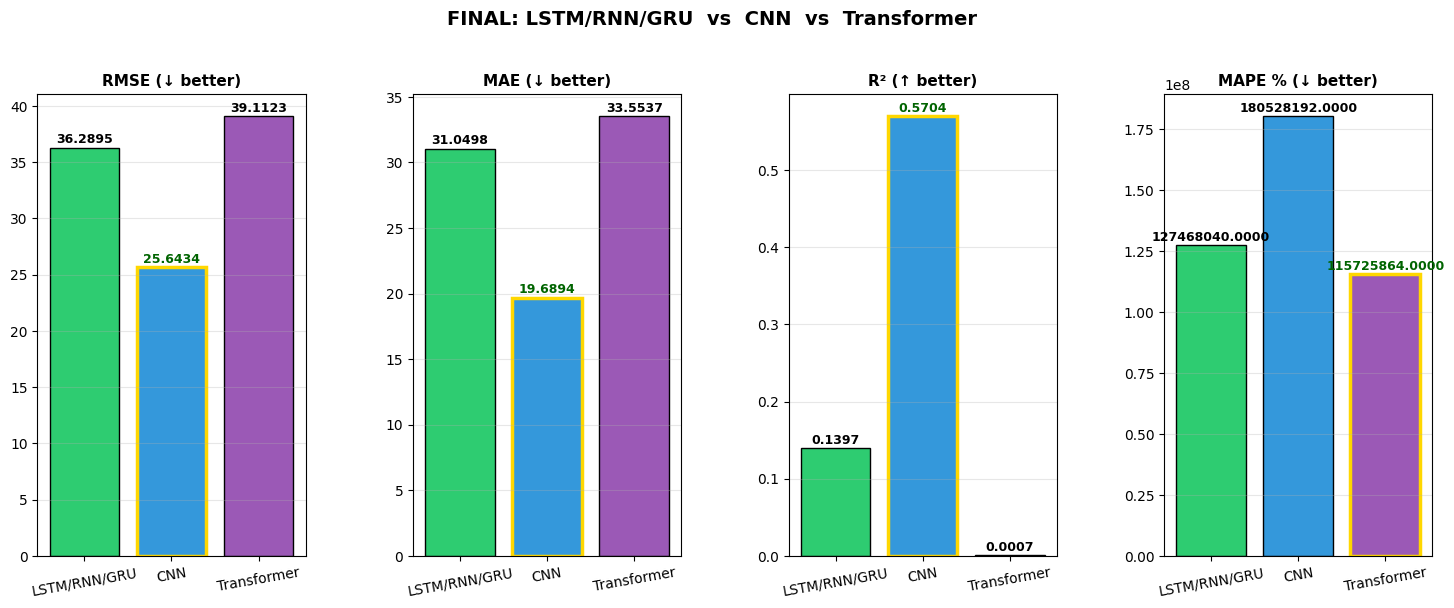

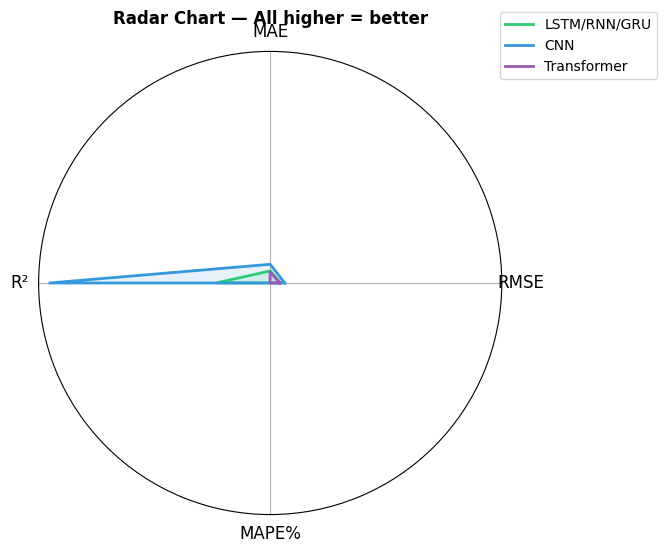

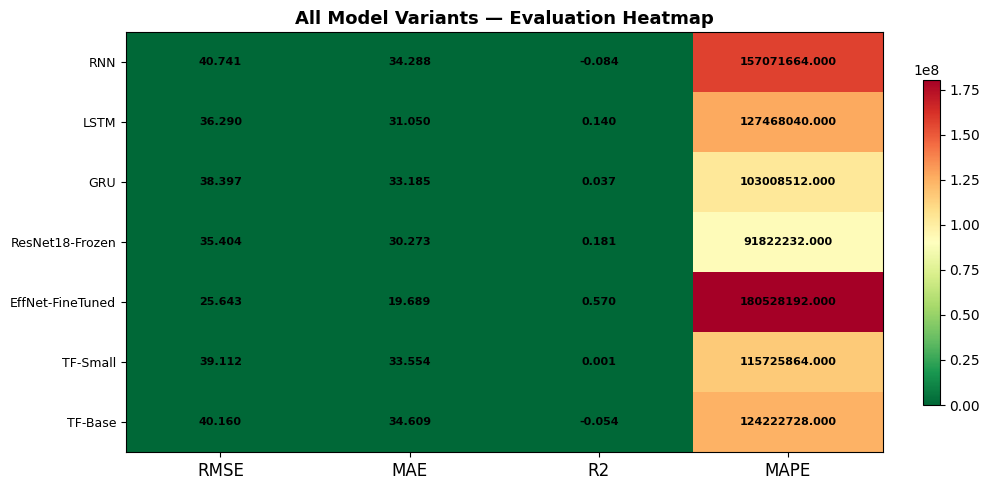


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
  🏆 Best Architecture : CNN
     Best Variant     : EffNet-FineTuned
     R²               : 0.5704
     RMSE             : 25.6434
     MAE              : 19.6894
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


In [13]:
# ─── CELL 12 : FINAL EVALUATION (unchanged) ──────────────────────────────────
print("\n" + "█"*60)
print("  FINAL EVALUATION — All 3 Architectures")
print("█"*60)

def best_variant(d):
    return max(d.items(), key=lambda kv: kv[1]['R2'])

summary_rows = []
for arch, d in [('LSTM/RNN/GRU', lstm_metrics),
                ('CNN',           cnn_metrics),
                ('Transformer',   tf_metrics)]:
    name, m = best_variant(d)
    summary_rows.append({'Architecture': arch, 'Best Variant': name,
                         'RMSE': round(m['RMSE'],4), 'MAE':  round(m['MAE'],4),
                         'R²':   round(m['R2'],4),   'MAPE%': round(m['MAPE'],2)})

SUMMARY = pd.DataFrame(summary_rows).set_index('Architecture')
print("\n"); display(SUMMARY)
SUMMARY.to_csv('/content/final_summary.csv')

# 4-panel bar chart
arch_names   = [r['Architecture'] for r in summary_rows]
colors_final = ['#2ecc71', '#3498db', '#9b59b6']
metric_info  = [('RMSE','RMSE (↓ better)',False), ('MAE','MAE (↓ better)',False),
                ('R²','R² (↑ better)',True),       ('MAPE%','MAPE % (↓ better)',False)]

fig = plt.figure(figsize=(18, 6))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.4)
for idx, (key, title, hb) in enumerate(metric_info):
    ax   = fig.add_subplot(gs[idx])
    vals = list(SUMMARY[key])
    bars = ax.bar(arch_names, vals, color=colors_final, edgecolor='k')
    bi   = (np.argmax if hb else np.argmin)(vals)
    for i, (b, v) in enumerate(zip(bars, vals)):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*.01,
                f'{v:.4f}', ha='center', fontsize=9,
                fontweight='bold', color='darkgreen' if i==bi else 'black')
    bars[bi].set_edgecolor('gold'); bars[bi].set_linewidth(2.5)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(arch_names, rotation=10); ax.grid(axis='y', alpha=.3)
plt.suptitle('FINAL: LSTM/RNN/GRU  vs  CNN  vs  Transformer',
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig('/content/final_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# Radar chart
df_r = SUMMARY[['RMSE','MAE','R²','MAPE%']].copy()
for col in ['RMSE','MAE','MAPE%']: df_r[col] = 1/(1+df_r[col])
mets = list(df_r.columns); N = len(mets)
angles = [n/N*2*math.pi for n in range(N)] + [0]
fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
for (arch, row), col in zip(df_r.iterrows(), colors_final):
    vals = row.tolist() + [row.tolist()[0]]
    ax.plot(angles, vals, color=col, linewidth=2, label=arch)
    ax.fill(angles, vals, color=col, alpha=0.12)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(mets, fontsize=12)
ax.set_yticks([]); ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1))
ax.set_title('Radar Chart — All higher = better', fontsize=12, pad=20, fontweight='bold')
plt.tight_layout(); plt.savefig('/content/radar_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# Heatmap
all_hm = {}
for prefix, d in [('LSTM',lstm_metrics),('CNN',cnn_metrics),('TF',tf_metrics)]:
    for name, m in d.items(): all_hm[name] = m
HM_DF = pd.DataFrame(all_hm).T[['RMSE','MAE','R2','MAPE']]
fig, ax = plt.subplots(figsize=(10, max(5, len(HM_DF)*.55+1)))
im = ax.imshow(HM_DF.values.astype(float), cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(HM_DF.columns))); ax.set_xticklabels(HM_DF.columns, fontsize=12)
ax.set_yticks(range(len(HM_DF.index)));   ax.set_yticklabels(HM_DF.index, fontsize=9)
for i in range(len(HM_DF.index)):
    for j in range(len(HM_DF.columns)):
        ax.text(j,i,f'{HM_DF.values[i,j]:.3f}',
                ha='center',va='center',fontsize=8,fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02)
ax.set_title('All Model Variants — Evaluation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('/content/metrics_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

best_arch = SUMMARY['R²'].idxmax()
print("\n" + "★"*55)
print(f"  🏆 Best Architecture : {best_arch}")
print(f"     Best Variant     : {SUMMARY.loc[best_arch,'Best Variant']}")
print(f"     R²               : {SUMMARY.loc[best_arch,'R²']:.4f}")
print(f"     RMSE             : {SUMMARY.loc[best_arch,'RMSE']:.4f}")
print(f"     MAE              : {SUMMARY.loc[best_arch,'MAE']:.4f}")
print("★"*55)


In [14]:
from google.colab import files

output_files = [
    '/content/final_summary.csv',
    '/content/final_comparison.png',
    '/content/radar_comparison.png',
    '/content/metrics_heatmap.png',
    '/content/lstm_results.png',
    '/content/lstm_attention.png',
    '/content/cnn_spatial_images.png',
    '/content/cnn_results.png',
    '/content/cnn_comparison.png',
    '/content/transformer_results.png',
    '/content/transformer_attention.png',
]

print("📥 Downloading output files...")
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f"  ✅ {f}")
    else:
        print(f"  ⚠️  {f} not found (cell may not have run yet)")

📥 Downloading output files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ /content/final_summary.csv


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ /content/transformer_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ /content/transformer_attention.png
